<a href="https://colab.research.google.com/github/KNaveenKumar8910/zepto-ai-platform/blob/main/analytics/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn seaborn matplotlib imbalanced-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, mean_squared_error,
    r2_score, mean_absolute_error
)
from imblearn.over_sampling import SMOTE
import joblib

# Load offline data fallback
df = pd.read_csv("titanic.csv")
print("Data shape:", df.shape)
df.info()

Data shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


Missing percentages:
 age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64
Fare Mean: 32.10, Median: 14.45, Mode: 8.05
age outliers: 8
fare outliers: 114
Survival by Sex:
 sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

Survival by Pclass:
 pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival by Sex & Pclass:
 sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


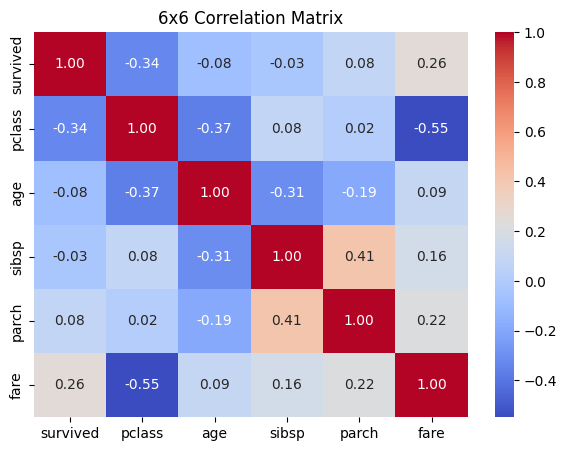

In [2]:
# Missing Value Evaluation
missing_pct = df.isnull().mean() * 100
print("Missing percentages:\n", missing_pct[missing_pct > 0])

# Clean according to rubric rules
df = df.drop(columns=['deck'])  # >30% missing
df = df.dropna(subset=['embarked', 'embark_town'])  # <5% missing

# Univariate Fare Skewness
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]
print(f"Fare Mean: {fare_mean:.2f}, Median: {fare_median:.2f}, Mode: {fare_mode:.2f}")

# IQR Outliers
for col in ['age', 'fare']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f"{col} outliers: {len(outliers)}")

# Bivariate survival breakdowns
print("Survival by Sex:\n", df.groupby('sex')['survived'].mean())
print("\nSurvival by Pclass:\n", df.groupby('pclass')['survived'].mean())
print("\nSurvival by Sex & Pclass:\n", df.groupby(['sex', 'pclass'])['survived'].mean())

# 6x6 Correlation matrix excluding redundant flags
num_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("6x6 Correlation Matrix")
plt.show()


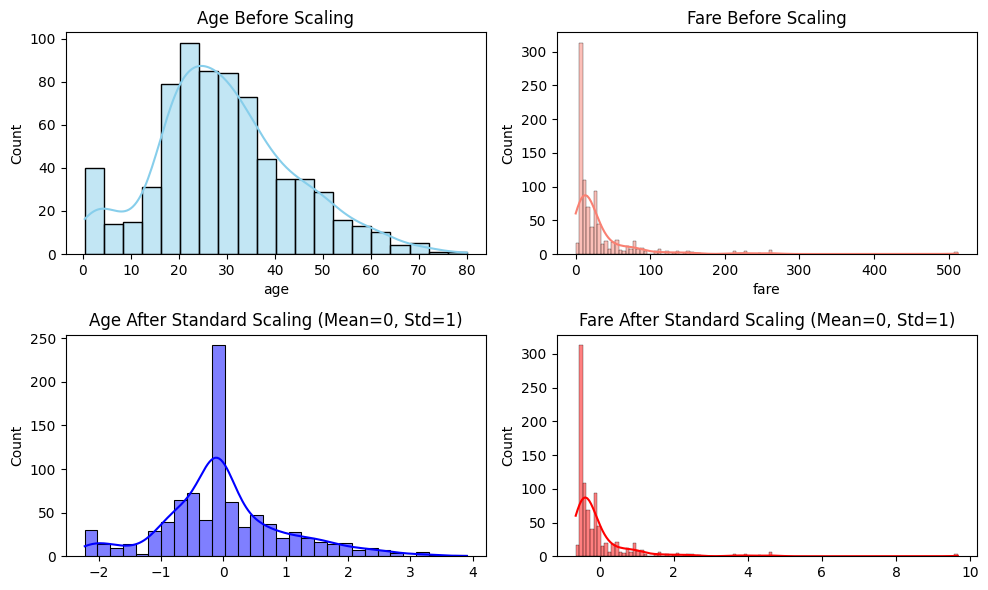

In [5]:
# 1. STANDARDIZATION CHECK (AGE & FARE)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0, 0], color='skyblue').set_title("Age Before Scaling")
sns.histplot(df['fare'], kde=True, ax=axes[0, 1], color='salmon').set_title("Fare Before Scaling")

scaler_check = StandardScaler()
scaled_vals = scaler_check.fit_transform(df[['age', 'fare']].fillna(df[['age', 'fare']].median()))
sns.histplot(scaled_vals[:, 0], kde=True, ax=axes[1, 0], color='blue').set_title("Age After Standard Scaling (Mean=0, Std=1)")
sns.histplot(scaled_vals[:, 1], kde=True, ax=axes[1, 1], color='red').set_title("Fare After Standard Scaling (Mean=0, Std=1)")
plt.tight_layout()
plt.show()

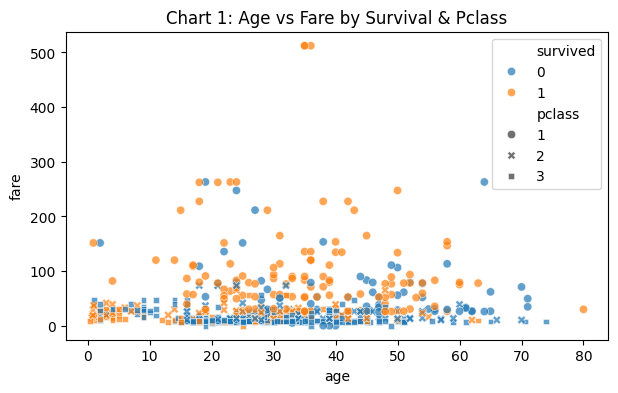

/tmp/ipykernel_1492/2449876282.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', hue='sex', ci=None)


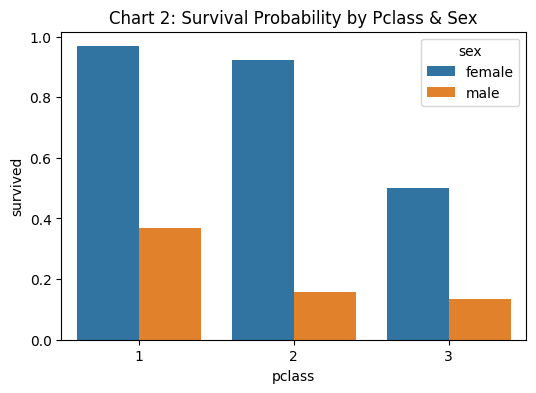

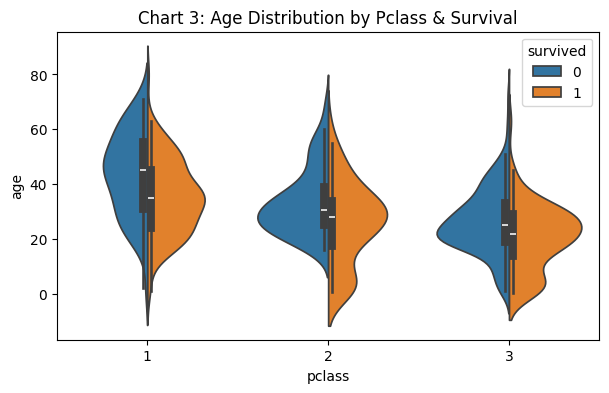

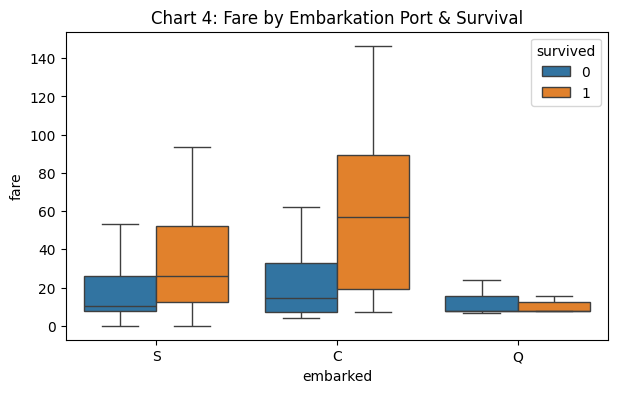

In [6]:
# 2. AT LEAST 4 MULTIVARIATE CHARTS
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='age', y='fare', hue='survived', style='pclass', alpha=0.7)
plt.title("Chart 1: Age vs Fare by Survival & Pclass")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='pclass', y='survived', hue='sex', ci=None)
plt.title("Chart 2: Survival Probability by Pclass & Sex")
plt.show()

plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x='pclass', y='age', hue='survived', split=True)
plt.title("Chart 3: Age Distribution by Pclass & Survival")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='embarked', y='fare', hue='survived', showfliers=False)
plt.title("Chart 4: Fare by Embarkation Port & Survival")
plt.show()

In [7]:
# Split target and features
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y = df['survived']

# Stratified split to maintain survival class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_features = ['age', 'fare', 'sibsp', 'parch']
cat_features = ['sex', 'embarked', 'pclass']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features)
])

# Fit classifiers
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, oob_score=True, random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "AUC": roc_auc_score(y_test, probs)
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.814607,0.79661,0.691176,0.740157,0.859626
Decision Tree,0.803371,0.80000,0.647059,0.715447,0.848128
Random Forest,0.831461,0.88000,0.647059,0.745763,0.839773


In [8]:
# Train-only SMOTE demonstration
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)

rf_sm = RandomForestClassifier(random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)
sm_preds = rf_sm.predict(X_test_proc)
print("SMOTE F1 Score:", f1_score(y_test, sm_preds))

# Save the full fitted end-to-end pipeline
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, oob_score=True, random_state=42))
])
best_pipeline.fit(X_train, y_train)
print("OOB Score:", best_pipeline.named_steps['classifier'].oob_score_)

joblib.dump(best_pipeline, "best_pipeline.joblib")
print("Saved best_pipeline.joblib successfully!")

SMOTE F1 Score: 0.7299270072992701
OOB Score: 0.8143459915611815
Saved best_pipeline.joblib successfully!


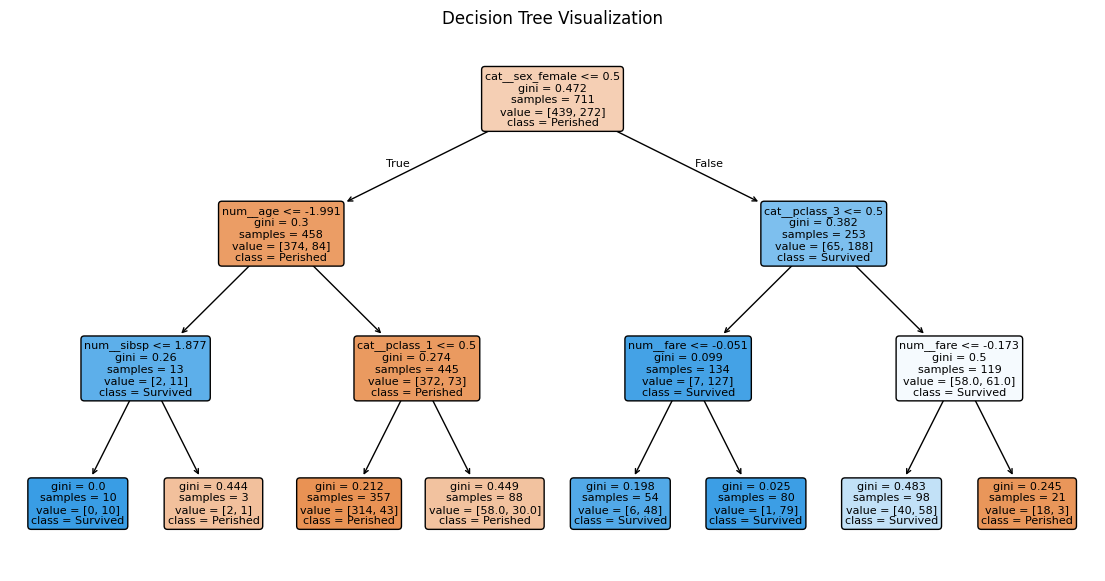

In [9]:
# 3. DECISION TREE VISUALIZATION (plot_tree)
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
pipe_dt = Pipeline([('preprocessor', preprocessor), ('clf', dt_clf)])
pipe_dt.fit(X_train, y_train)

plt.figure(figsize=(14, 7))
plot_tree(pipe_dt.named_steps['clf'], filled=True, feature_names=pipe_dt.named_steps['preprocessor'].get_feature_names_out(), class_names=['Perished', 'Survived'], rounded=True, fontsize=8)
plt.title("Decision Tree Visualization")
plt.show()

In [10]:
# 4. 3-WAY IMBALANCE COMPARISON (Baseline vs Balanced vs SMOTE)
rf_base = RandomForestClassifier(random_state=42).fit(X_train_proc, y_train)
rf_bal = RandomForestClassifier(class_weight='balanced', random_state=42).fit(X_train_proc, y_train)

f1_base = f1_score(y_test, rf_base.predict(X_test_proc))
f1_bal = f1_score(y_test, rf_bal.predict(X_test_proc))
f1_smote = f1_score(y_test, rf_sm.predict(X_test_proc))

print(f"Imbalance Comparison -> Baseline F1: {f1_base:.4f} | Balanced Class Weight F1: {f1_bal:.4f} | SMOTE F1: {f1_smote:.4f}")

Imbalance Comparison -> Baseline F1: 0.7519 | Balanced Class Weight F1: 0.7424 | SMOTE F1: 0.7299


In [11]:
# 5. GRIDSEARCHCV ON RANDOM FOREST WITH OOB SCORE
param_grid = {'classifier__n_estimators': [50, 100], 'classifier__max_depth': [3, 5]}
rf_oob = RandomForestClassifier(oob_score=True, random_state=42)
pipe_rf = Pipeline([('preprocessor', preprocessor), ('classifier', rf_oob)])

grid = GridSearchCV(pipe_rf, param_grid, cv=3, scoring='f1')
grid.fit(X_train, y_train)
print(f"GridSearchCV Best Params: {grid.best_params_}")
print(f"GridSearchCV Best Estimator OOB Score: {grid.best_estimator_.named_steps['classifier'].oob_score_:.4f}")

GridSearchCV Best Params: {'classifier__max_depth': 5, 'classifier__n_estimators': 100}
GridSearchCV Best Estimator OOB Score: 0.8143


In [12]:
# 6. REGRESSION SUB-TASK (Predicting Fare) & HETEROSCEDASTICITY CHECK
reg_features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']
X_reg = df[reg_features]
y_reg = df['fare']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), ['age', 'sibsp', 'parch']),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), ['sex', 'embarked', 'pclass'])
])

reg_pipe = Pipeline([('prep', reg_preprocessor), ('reg', LinearRegression())])
reg_pipe.fit(X_reg_train, y_reg_train)
reg_preds = reg_pipe.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, reg_preds)
mse = mean_squared_error(y_reg_test, reg_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, reg_preds)

print(f"Fare Regression Metrics -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

Fare Regression Metrics -> MAE: 17.85, MSE: 1644.10, RMSE: 40.55, R2: 0.3838


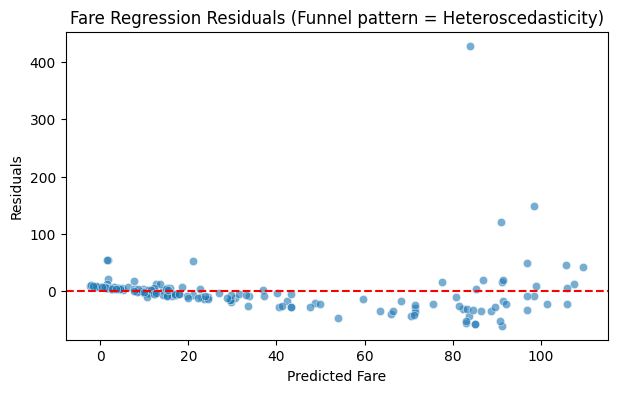

In [13]:
# Heteroscedasticity plot
residuals = y_reg_test - reg_preds
plt.figure(figsize=(7, 4))
sns.scatterplot(x=reg_preds, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Fare Regression Residuals (Funnel pattern = Heteroscedasticity)")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.show()